# Week 2 — Forward Process Moments: E[x_t | x_0] and Var(x_t | x_0)

## Learning Objectives

By the end of this notebook, you will:
1. Understand the derivation of **E[x_t | x_0] = x_0** using linearity of expectation
2. Understand the derivation of **Var(x_t | x_0) = σ²(t)** using variance rules
3. Empirically verify both results with code

## Why This Matters for Diffusion Models

Understanding the statistics of the forward process is foundational:
- **Mean = x_0**: The expected noisy sample is exactly the original point (noise averages out)
- **Variance = σ²(t)**: The spread of noisy samples grows predictably with the noise schedule

These moments tell us:
- Where noisy samples are centered (at x_0)
- How dispersed they become (controlled by σ)

This connects directly to what a denoising model needs to learn!

---
## Section 0: Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [3]:
def forward_noise(x_0, sigma):
    """
    Add Gaussian noise to data points.
    
    Args:
        x_0: Original data, shape (n_samples, d) or scalar
        sigma: Noise level (scalar)
    
    Returns:
        x_t: Noisy data, same shape as x_0
    
    Formula: x_t = x_0 + sigma * epsilon
    where epsilon ~ N(0, I)
    """
    x_0 = np.atleast_1d(x_0)
    eps = np.random.randn(*x_0.shape)
    x_t = x_0 + sigma * eps
    return x_t

---
## Section 1: The Derivations

Derivation done by hand, then convert to markdown.

Recall the forward process formula:

$$x_t = x_0 + \sigma(t) \cdot \varepsilon$$

where:
- $x_0$ is the original data point (given/fixed when we condition on it)
- $\sigma(t)$ is the noise level at time $t$ (a deterministic function)
- $\varepsilon \sim \mathcal{N}(0, I)$ is standard Gaussian noise, independent of $x_0$

### Derivation of E[x_t | x_0]

**Goal:** Find the expected value of $x_t$ given that we know $x_0$.

$$\mathbb{E}[x_t \mid x_0] = \mathbb{E}[x_0 + \sigma(t) \varepsilon \mid x_0]$$

**Step 1: Linearity of expectation**

$$= \mathbb{E}[x_0 \mid x_0] + \mathbb{E}[\sigma(t) \varepsilon \mid x_0]$$

**Step 2: x_0 is constant given x_0**

Since we're conditioning on $x_0$, it's no longer random — it's a known constant:

$$\mathbb{E}[x_0 \mid x_0] = x_0$$

**Step 3: σ(t) is a constant**

The noise schedule $\sigma(t)$ is deterministic, so we can pull it out:

$$\mathbb{E}[\sigma(t) \varepsilon \mid x_0] = \sigma(t) \cdot \mathbb{E}[\varepsilon \mid x_0]$$

**Step 4: ε is independent of x_0**

Since $\varepsilon$ is independent of $x_0$, conditioning on $x_0$ doesn't change its distribution:

$$\mathbb{E}[\varepsilon \mid x_0] = \mathbb{E}[\varepsilon] = 0$$

(The mean of standard Gaussian noise is 0)

**Result:**

$$\boxed{\mathbb{E}[x_t \mid x_0] = x_0}$$

**Interpretation:** The expected noisy sample equals the original point. Noise adds randomness but doesn't shift the center.

### Derivation of Var(x_t | x_0)

**Goal:** Find the variance of $x_t$ given $x_0$.

$$\text{Var}(x_t \mid x_0) = \text{Var}(x_0 + \sigma(t) \varepsilon \mid x_0)$$

**Step 1: Variance rule for Var(b + aZ)**

Recall that for constants $a, b$ and random variable $Z$:

$$\text{Var}(b + aZ) = a^2 \text{Var}(Z)$$

(Adding a constant doesn't change variance; scaling by $a$ scales variance by $a^2$)

**Step 2: Identify the constants**

Given $x_0$:
- $x_0$ is constant (the "$b$" in our formula)
- $\sigma(t)$ is constant (the "$a$" in our formula)
- $\varepsilon$ is the random variable (the "$Z$")

So:

$$\text{Var}(x_0 + \sigma(t) \varepsilon \mid x_0) = \sigma^2(t) \cdot \text{Var}(\varepsilon \mid x_0)$$

**Step 3: ε is independent of x_0**

$$\text{Var}(\varepsilon \mid x_0) = \text{Var}(\varepsilon) = 1$$

(The variance of standard Gaussian noise is 1)

**Result:**

$$\boxed{\text{Var}(x_t \mid x_0) = \sigma^2(t)}$$

**Interpretation:** The spread of noisy samples is exactly controlled by the noise schedule. Larger $\sigma$ means more spread.

---
## Section 2: Empirical Verification — Mean

Let's verify that $\mathbb{E}[x_t \mid x_0] = x_0$ by sampling many $x_t$ values for a fixed $x_0$.

**The Experiment:**
1. Fix a specific value of $x_0$ (say, $x_0 = 3.0$)
2. Fix a noise level $\sigma$ (say, $\sigma = 1.5$)
3. Sample many $x_t$ values (10,000 samples)
4. Compute the empirical mean
5. Compare to the theoretical mean ($x_0$)

**Your task:** Implement the sampling and compute the empirical mean.

In [4]:
# Parameters
x_0_fixed = 3.0        # Our fixed starting point
sigma_fixed = 1.5      # Fixed noise level
n_samples = 10000      # Number of samples to draw

# Theoretical values
theoretical_mean = x_0_fixed
theoretical_variance = sigma_fixed ** 2

print(f"Theoretical E[x_t | x_0] = {theoretical_mean}")
print(f"Theoretical Var(x_t | x_0) = {theoretical_variance}")

Theoretical E[x_t | x_0] = 3.0
Theoretical Var(x_t | x_0) = 2.25


In [5]:
# TODO: Sample many x_t values for our fixed x_0
#
# Hint: We want to call forward_noise many times with the same x_0.
# One efficient way: create an array of n_samples copies of x_0,
# then call forward_noise once.
#
# x_0_array should have shape (n_samples,) with all values = x_0_fixed

np.random.seed(42)  # For reproducibility

x_0_array = [x_0_fixed] * n_samples
x_t_samples = forward_noise(x_0=x_0_array, sigma=sigma_fixed)

print(f"x_t_samples shape: {x_t_samples.shape}")
print(f"First 5 samples: {x_t_samples[:5]}")

x_t_samples shape: (10000,)
First 5 samples: [3.74507123 2.79260355 3.97153281 5.28454478 2.64876994]


In [6]:
# TODO: Compute the empirical mean of x_t_samples
#
# Hint: Use np.mean()

empirical_mean = np.mean(x_t_samples)

print(f"Empirical mean:    {empirical_mean:.4f}")
print(f"Theoretical mean:  {theoretical_mean:.4f}")
print(f"Difference:        {abs(empirical_mean - theoretical_mean):.4f}")

Empirical mean:    2.9968
Theoretical mean:  3.0000
Difference:        0.0032


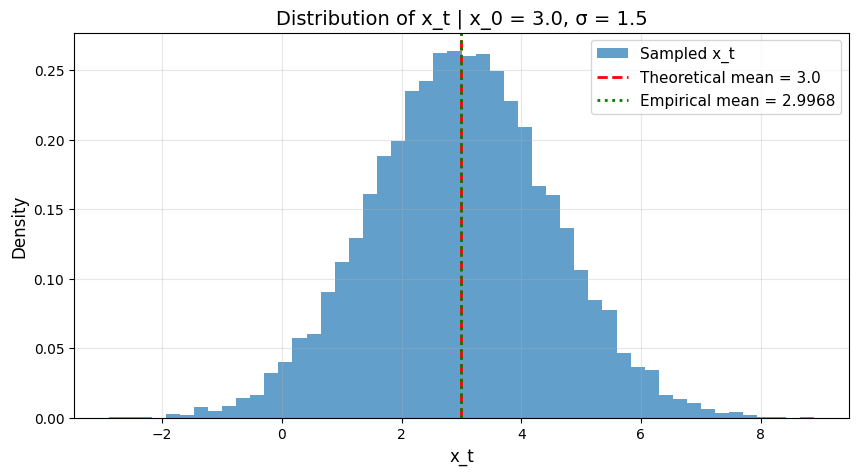

In [7]:
# Visualization: histogram of samples with theoretical mean marked
plt.figure(figsize=(10, 5))
plt.hist(x_t_samples, bins=50, density=True, alpha=0.7, label='Sampled x_t')
plt.axvline(x=theoretical_mean, color='red', linestyle='--', linewidth=2, 
            label=f'Theoretical mean = {theoretical_mean}')
plt.axvline(x=empirical_mean, color='green', linestyle=':', linewidth=2,
            label=f'Empirical mean = {empirical_mean:.4f}')
plt.xlabel('x_t', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title(f'Distribution of x_t | x_0 = {x_0_fixed}, σ = {sigma_fixed}', fontsize=14)
plt.legend(fontsize=11)
plt.show()

**Checkpoint:** The empirical mean should be very close to $x_0 = 3.0$ (within ~0.05 for 10,000 samples).

---
## Section 3: Empirical Verification — Variance

Now let's verify that $\text{Var}(x_t \mid x_0) = \sigma^2(t)$.

**Your task:** Using the same samples from Section 2, compute the empirical variance.

In [8]:
# TODO: Compute the empirical variance of x_t_samples
#
# Hint: Use np.var()

empirical_variance = np.var(x_t_samples)

print(f"Empirical variance:   {empirical_variance:.4f}")
print(f"Theoretical variance: {theoretical_variance:.4f}")
print(f"Difference:           {abs(empirical_variance - theoretical_variance):.4f}")

Empirical variance:   2.2654
Theoretical variance: 2.2500
Difference:           0.0154


**Checkpoint:** The empirical variance should be very close to $\sigma^2 = 2.25$ (within ~0.1 for 10,000 samples).

---
## Section 4: Verify Across Different σ Values

Let's verify that our formulas hold for **multiple** values of $\sigma$.

**The Experiment:**
1. Choose several σ values: 0.1, 0.5, 1.0, 2.0
2. For each σ: sample many x_t, compute empirical mean and variance
3. Compare to theoretical values
4. Plot the results

**Your task:** Implement the loop over σ values.

In [9]:
# Parameters
x_0_fixed = 3.0
sigma_values = [0.1, 0.5, 1.0, 2.0]
n_samples = 10000

# Storage for results
empirical_means = []
empirical_variances = []
theoretical_means = []
theoretical_variances = []

In [10]:
# TODO: Loop over sigma_values and compute empirical/theoretical statistics
#
# For each sigma:
#   1. Set np.random.seed(42) for reproducibility
#   2. Create x_0_array (n_samples copies of x_0_fixed)
#   3. Apply forward_noise to get x_t_samples
#   4. Compute empirical mean and variance
#   5. Compute theoretical mean (x_0_fixed) and variance (sigma^2)
#   6. Append all values to the respective lists

for sigma in sigma_values:
    np.random.seed(42)
    
    x_0_array = [x_0_fixed] * n_samples
    x_t_samples = forward_noise(x_0=x_0_array, sigma=sigma)
    
    emp_mean = np.mean(x_t_samples)
    emp_var = np.var(x_t_samples)
    
    theo_mean = x_0_fixed
    theo_var = sigma ** 2
    
    # Append to lists
    empirical_means.append(emp_mean)
    empirical_variances.append(emp_var)
    theoretical_means.append(theo_mean)
    theoretical_variances.append(theo_var)

In [11]:
# Display results in a table
print("Results Summary")
print("=" * 70)
print(f"{'σ':>6} | {'Emp Mean':>10} | {'Theo Mean':>10} | {'Emp Var':>10} | {'Theo Var':>10}")
print("-" * 70)
for i, sigma in enumerate(sigma_values):
    print(f"{sigma:>6.1f} | {empirical_means[i]:>10.4f} | {theoretical_means[i]:>10.4f} | {empirical_variances[i]:>10.4f} | {theoretical_variances[i]:>10.4f}")
print("=" * 70)

Results Summary
     σ |   Emp Mean |  Theo Mean |    Emp Var |   Theo Var
----------------------------------------------------------------------
   0.1 |     2.9998 |     3.0000 |     0.0101 |     0.0100
   0.5 |     2.9989 |     3.0000 |     0.2517 |     0.2500
   1.0 |     2.9979 |     3.0000 |     1.0068 |     1.0000
   2.0 |     2.9957 |     3.0000 |     4.0273 |     4.0000


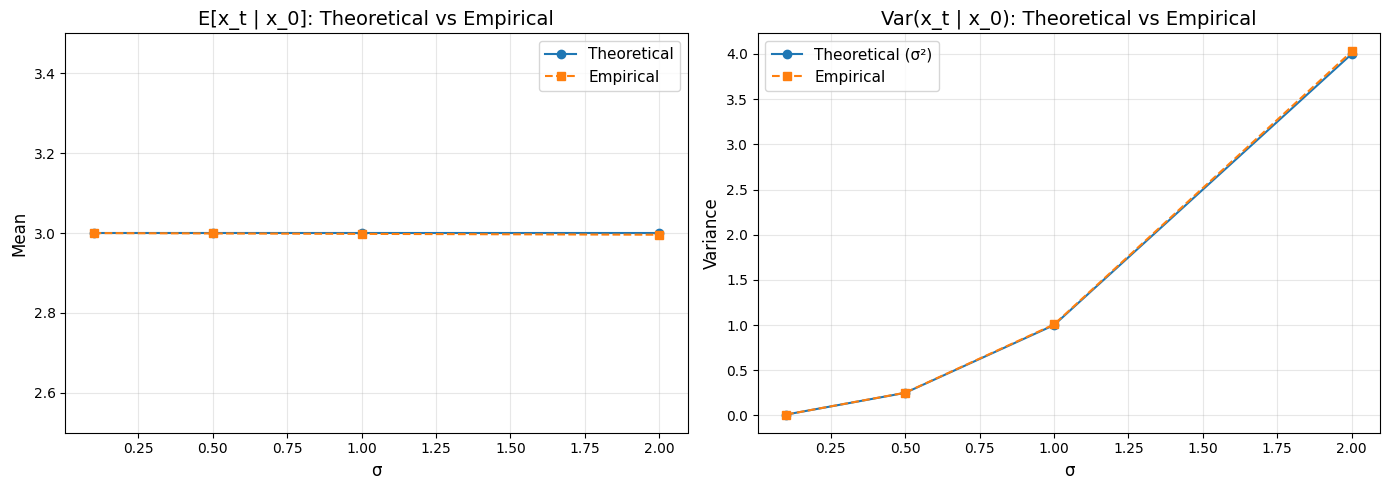

In [13]:
# TODO: Create a 2-panel figure
# Left panel: theoretical vs empirical MEAN (should all be ~x_0)
# Right panel: theoretical vs empirical VARIANCE (should follow σ² line)
#
# Hint: Use plt.subplots(1, 2, ...)
# For the variance plot, it helps to also plot the line y = σ² for reference

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Mean comparison
ax1 = axes[0]
ax1.plot(sigma_values, theoretical_means, 'o-', label='Theoretical')
ax1.plot(sigma_values, empirical_means, 's--', label='Empirical')
ax1.set_xlabel('σ', fontsize=12)
ax1.set_ylabel('Mean', fontsize=12)
ax1.set_title('E[x_t | x_0]: Theoretical vs Empirical', fontsize=14)
ax1.legend(fontsize=11)
ax1.set_ylim([x_0_fixed - 0.5, x_0_fixed + 0.5])  # Zoom in to see differences

# Right panel: Variance comparison
ax2 = axes[1]
ax2.plot(sigma_values, theoretical_variances, 'o-', label='Theoretical (σ²)')
ax2.plot(sigma_values, empirical_variances, 's--', label='Empirical')
ax2.set_xlabel('σ', fontsize=12)
ax2.set_ylabel('Variance', fontsize=12)
ax2.set_title('Var(x_t | x_0): Theoretical vs Empirical', fontsize=14)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

**Checkpoint:** 
- Left plot: Both lines should be flat at $x_0 = 3.0$
- Right plot: Empirical variance should closely follow the theoretical $\sigma^2$ curve

---
## Section 5: Key Takeaways

### What We Derived and Verified

| Property | Formula | Intuition |
|----------|---------|----------|
| **Mean** | $\mathbb{E}[x_t \mid x_0] = x_0$ | Noise averages to zero, so the center stays at $x_0$ |
| **Variance** | $\text{Var}(x_t \mid x_0) = \sigma^2(t)$ | Spread is controlled purely by the noise schedule |

### Key Tools Used

1. **Linearity of expectation**: $\mathbb{E}[aX + bY] = a\mathbb{E}[X] + b\mathbb{E}[Y]$
2. **Variance scaling rule**: $\text{Var}(aX + b) = a^2 \text{Var}(X)$
3. **Independence**: $\mathbb{E}[X \mid Y] = \mathbb{E}[X]$ when $X \perp Y$
4. **Law of Large Numbers**: Empirical statistics converge to theoretical values

### Connection to Diffusion Models

These moments are essential for understanding diffusion:

- **The mean stays at x_0**: This tells us the denoising model's "target" — it should learn to predict the original point
- **The variance grows with σ²(t)**: This tells us how uncertain we become as noise increases

In the full DDPM formulation, you'll see:
$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \varepsilon$$

The moments become:
- $\mathbb{E}[x_t \mid x_0] = \sqrt{\bar{\alpha}_t} x_0$ (mean shrinks toward 0)
- $\text{Var}(x_t \mid x_0) = 1 - \bar{\alpha}_t$ (variance bounded by 1)

But the same derivation techniques apply!

---
## Done!

Congratulations on completing Week 2 Diffusion Contact.

**What you accomplished:**
- Derived $\mathbb{E}[x_t \mid x_0] = x_0$ step-by-step
- Derived $\text{Var}(x_t \mid x_0) = \sigma^2(t)$ step-by-step
- Empirically verified both results with sampling
- Confirmed the formulas hold across multiple σ values

**Artifacts produced:**
- This notebook (`notebooks/w02_forward_moments.ipynb`)